In [1]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=cy658dzw').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://refinance-speaker-stopped-formed.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)


준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.0.2
pandas: 2.2.2


In [3]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 데이터가 모두 준비됩니다.
# (실제 현장처럼 '오염'을 일부러 심어 둡니다: 결측·이상치·표기 혼재·날짜 포맷 혼재·중복)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers)
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})
# 오염 심기: 나이 이상치, 결측, 지역/멤버십 표기 혼재
customers.loc[5, "age"] = 999          # 입력 실수로 보이는 이상치
customers.loc[10, "age"] = -3          # 음수 나이(불가능한 값)
customers.loc[[20, 21, 22], "gender"] = np.nan
customers.loc[30, "region"] = " 서울 "  # 앞뒤 공백
customers.loc[31, "region"] = "Seoul"   # 영문 표기 혼재
customers.loc[40, "membership"] = "VIP"  # 대소문자 혼재

# 2) 상품(products)
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders)
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05]),
})

# 날짜 포맷 혼재(문자열로 저장 — 일부러 통일하지 않음)
base_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D")
date_strings = []
for i, d in enumerate(base_dates):
    if i % 3 == 0:
        date_strings.append(d.strftime("%Y-%m-%d"))
    elif i % 3 == 1:
        date_strings.append(d.strftime("%Y/%m/%d"))
    else:
        date_strings.append(d.strftime("%Y%m%d"))
orders["order_date"] = date_strings

# 오염 심기: 금액 결측, 수량 이상치, 중복 행
orders.loc[np.random.choice(n_orders, 35, replace=False), "amount"] = np.nan
orders.loc[7, "quantity"] = 100        # 비정상적으로 큰 주문 수량
orders = pd.concat([orders, orders.iloc[[0, 1]]], ignore_index=True)  # 중복 주문 2건

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (300, 5) | products: (40, 3) | orders: (2002, 7)


In [4]:
# 데이터가 어떻게 생겼는지 맨 위 몇 줄만 살짝 들여다봅니다.
print("=== orders (주문) ===")
display(orders.head())
print("\n=== customers (고객) ===")
display(customers.head())

=== orders (주문) ===


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0040,P017,1,19900.0,web,2025-03-25
1,O00002,C0224,P022,1,89900.0,app,2025/04/24
2,O00003,C0115,P034,1,49900.0,app,20250405
3,O00004,C0186,P029,1,89900.0,web,2025-01-04
4,O00005,C0056,P004,3,149700.0,web,2025/04/28



=== customers (고객) ===


,customer_id,age,gender,region,membership
0,C0001,39,M,경기,premium
1,C0002,34,F,부산,basic
2,C0003,41,F,서울,premium
3,C0004,49,M,대구,vip
4,C0005,33,M,서울,basic


In [5]:
# 3) describe — 숫자 열의 수치 검사
display(orders.describe())
print("\n[customers의 나이]")
display(customers["age"].describe())

,quantity,amount
count,2002.000000,1967.000000
mean,1.703297,79768.632435
std,2.319308,76692.530665
min,1.000000,9900.000000
25%,1.000000,19900.000000
50%,1.000000,49900.000000
75%,2.000000,99800.000000
max,100.000000,389700.000000



[customers의 나이]


,age
count,300.000000
mean,38.070000
std,56.408434
min,-3.000000
25%,29.000000
50%,36.000000
75%,41.000000
max,999.000000


In [7]:
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
bike.head()

INFO:werkzeug:127.0.0.1 - - [09/Jul/2026 08:46:15] "GET /ping HTTP/1.1" 200 -


따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포


In [8]:
# 시나리오 1 — 구조 진단
print("shape:", bike.shape)
bike.info()
display(bike.describe())

shape: (181, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[ns]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 7.2+ KB


,date,rentals,avg_temp,rainfall
count,181,173.000000,181.000000,181.000000
mean,2025-03-31 00:31:49.392265216,4531.757225,14.169061,5.298343
min,2025-01-01 00:00:00,2514.000000,-4.900000,0.000000
25%,2025-02-14 00:00:00,3841.000000,5.100000,0.000000
50%,2025-03-31 00:00:00,4708.000000,13.100000,0.000000
75%,2025-05-15 00:00:00,5243.000000,20.600000,5.000000
max,2025-06-29 00:00:00,6388.000000,250.000000,30.000000
std,NaN,889.609013,19.742786,9.687303


In [9]:
# 시나리오 2 — 품질 진단
print("[결측치]")
print(bike.isnull().sum())
print("\n중복 행:", bike.duplicated().sum())
print("\n[station_area 값의 종류]")
print(bike["station_area"].unique())
print("\n기온 이상치 확인(상위 3개):")
print(bike["avg_temp"].sort_values(ascending=False).head(3).tolist())

[결측치]
date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

중복 행: 1

[station_area 값의 종류]
['마포' ' 강남 ' '강남' '송파' '종로']

기온 이상치 확인(상위 3개):
[250.0, 31.8, 30.6]


In [19]:
# 이상치 제거 후 값 출력
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])

# 마지막 날짜 값 보기
print('마지막 날짜:',clean["date"].max())
# 렌탈 평균
print('렌탈 평균:',clean["rentals"].mean())

마지막 날짜: 2025-06-29 00:00:00
렌탈 평균: 4525.03488372093


# 따릉이 대여 데이터 — 기초 EDA 리포트

## 1. 데이터 개요
- 행/열: (181행, 5열)
- 기간: 2025-01-01 ~ 2025-06-29
- 주요 컬럼: date, rentals, avg_temp, rainfall, station_area

## 2. 구조 진단 (shape / info / describe)
- 자료형 요약: date(일자,datetime),rentals(실수,float),avg_temp(실수,float),rainfall(정수,int),station_area(문자,object)
- 수치 요약에서 눈에 띈 점: 일부 데이터가 250도로 기록됬다면 오류가 날 때 해당 기계의 특성으로 250도를 출력하는 것일 수도, 강수량이 적을 때 사용량이 올라가는 것은 이해되지만, 중간 공백이 있고 갑자기 강수량이 늘어난 30 지점에 사용량이 몰린 것은 이해가 가지 않음 (rentals 평균 4525.03488372093, avg_temp 최댓값 250 → 이상치 의심)

## 3. 품질 진단 (결측 / 중복 / 표기)
- 결측: rentals 8 건
- 중복: 1 건
- 표기 혼재: station_area에 ' 강남 '(강남 단어 앞 뒤 공백 1칸) 존재

## 4. 패턴 (시각화에서 읽은 것)
- 추이: 1월부터 늘어남. 3~4월이 많고, 다시 7월까지 내려가서 1월과 비슷해짐 (날씨가 따뜻해지면서 늘고 봄까지 더워지면서 줄어듬)
- 관계: 10~15도 근처가 제일 사용량이 많음. 여기서 더 추워지거나 더워지면 사용량 줄음.

## 5. 다음 분석 제안
- (데이터 품질이 안 좋은 경우) 필수적인 값이 비었다면 행 전체를 드롭해야 할 것 같고, 온도 같은 부분이라면 비슷한 일자의 데이터로 채워야 할 듯.
- 강수량과의 관계는 비가 안 오면 사용량이 당연히 느는데, 일부 데이터가 이해가 안 가는 것이 있음. 강수량 30 부근에 사용량이 몰려 있음. 분석해야 할 듯.

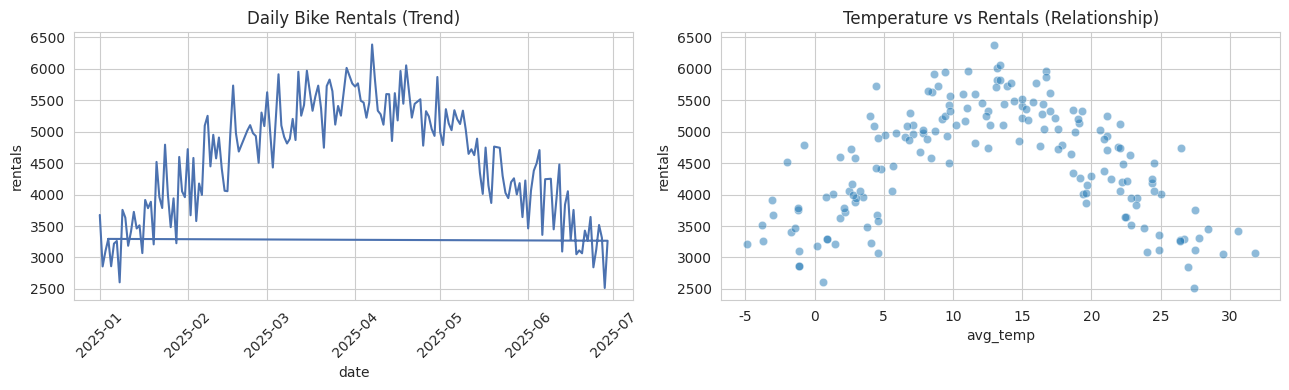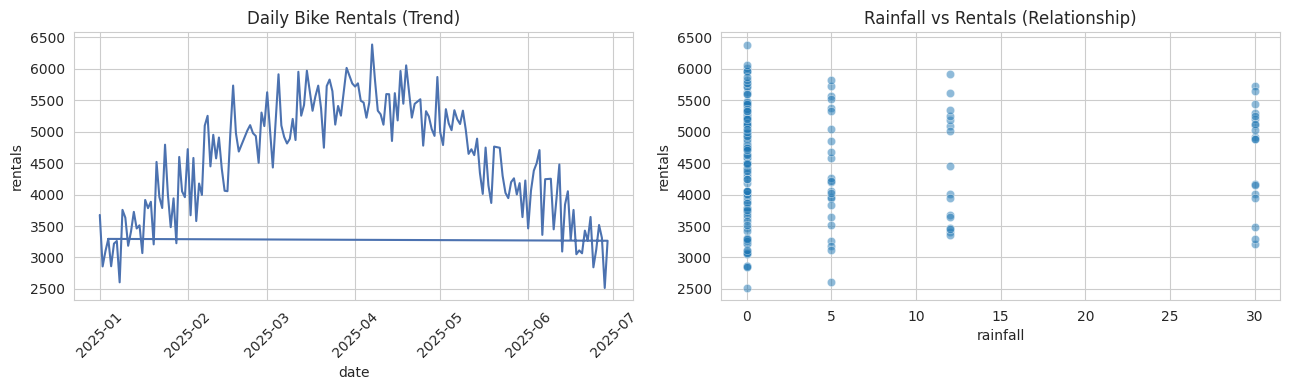